In [1]:
import os
import json
import random
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt

from transformers import AutoImageProcessor, SiglipVisionModel

/home/eraale/WS_linux/26yaicon1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
DATA_DIR = "arena_dataset"

MODEL_NAME = "google/siglip-base-patch16-224"
SAVE_PATH = "siglip_arena_classifier.pt"

CLASS_NAMES = [
    "no_entity",

    "far_zombie",
    "near_left_zombie",
    "near_right_zombie",
    "near_center_zombie",

    "far_skeleton",
    "near_left_skeleton",
    "near_right_skeleton",
    "near_center_skeleton",
]

NUM_CLASSES = len(CLASS_NAMES)

BATCH_SIZE = 16
EPOCHS = 10
LR = 2e-5
VAL_RATIO = 0.15
SEED = 42

FREEZE_ENCODER = False
USE_AMP = True

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("device:", device)

if device == "cuda":
    print(torch.cuda.get_device_name(0))
    print("VRAM GB:", torch.cuda.get_device_properties(0).total_memory / 1024**3)

device: cuda
NVIDIA GeForce RTX 4070 SUPER
VRAM GB: 11.99365234375


In [4]:
def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

In [5]:
def read_class_id(data):
    if "class_id" in data:
        return int(data["class_id"])

    if "label" in data and "class_id" in data["label"]:
        return int(data["label"]["class_id"])

    raise KeyError("class_id not found")


def load_samples(data_dir):
    samples = []

    for name in sorted(os.listdir(data_dir)):
        if not name.endswith(".json"):
            continue

        json_path = os.path.join(data_dir, name)
        stem = os.path.splitext(name)[0]
        image_path = os.path.join(data_dir, stem + ".png")

        if not os.path.exists(image_path):
            continue

        try:
            with open(json_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            class_id = read_class_id(data)

            if 0 <= class_id < NUM_CLASSES:
                samples.append((image_path, class_id))
            else:
                print("invalid class_id:", json_path, class_id)

        except Exception as e:
            print("skip:", json_path, e)

    return samples


samples = load_samples(DATA_DIR)

print("total samples:", len(samples))
print(Counter([x[1] for x in samples]))

for i, name in enumerate(CLASS_NAMES):
    print(i, name, Counter([x[1] for x in samples])[i])

total samples: 1095
Counter({1: 136, 0: 133, 8: 129, 3: 128, 6: 125, 4: 115, 5: 114, 7: 112, 2: 103})
0 no_entity 133
1 far_zombie 136
2 near_left_zombie 103
3 near_right_zombie 128
4 near_center_zombie 115
5 far_skeleton 114
6 near_left_skeleton 125
7 near_right_skeleton 112
8 near_center_skeleton 129


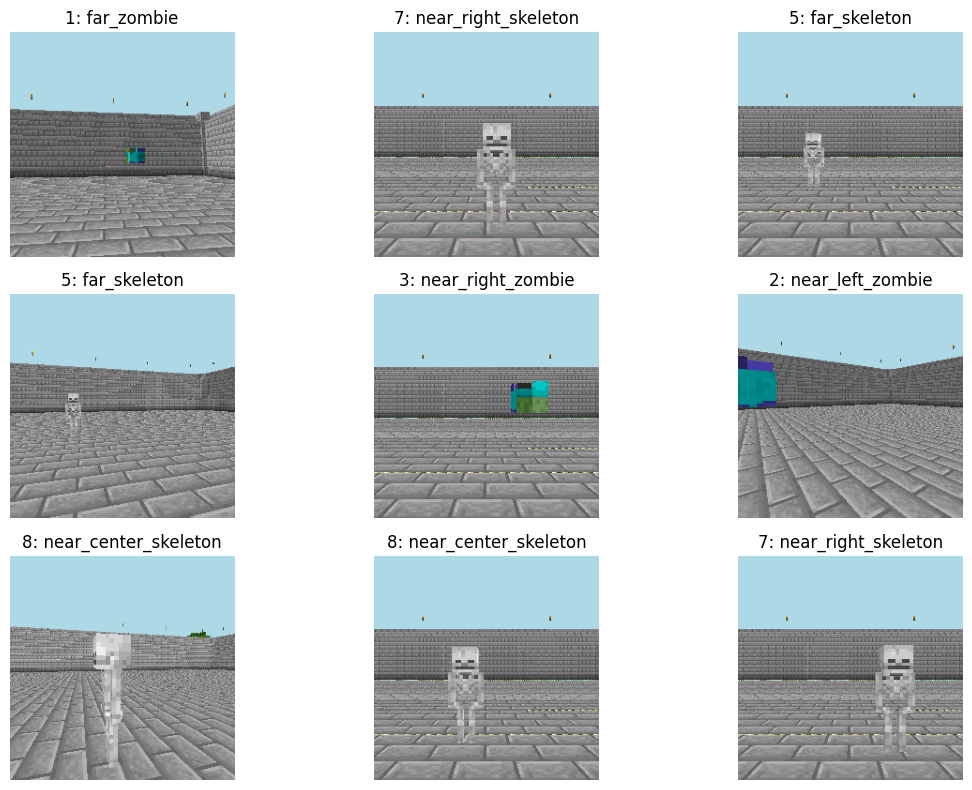

In [9]:
def show_samples(samples, n=9):
    picks = random.sample(samples, min(n, len(samples)))

    plt.figure(figsize=(12, 8))

    for i, (image_path, class_id) in enumerate(picks):
        img = Image.open(image_path).convert("RGB")

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(f"{class_id}: {CLASS_NAMES[class_id]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_samples(samples, 9)

In [10]:
labels = [x[1] for x in samples]

train_samples, val_samples = train_test_split(
    samples,
    test_size=VAL_RATIO,
    random_state=SEED,
    stratify=labels,
)

print("train:", len(train_samples))
print("val:", len(val_samples))

print("train dist:", Counter([x[1] for x in train_samples]))
print("val dist:", Counter([x[1] for x in val_samples]))

train: 930
val: 165
train dist: Counter({1: 115, 0: 113, 8: 110, 3: 109, 6: 106, 4: 98, 5: 97, 7: 95, 2: 87})
val dist: Counter({1: 21, 0: 20, 8: 19, 6: 19, 3: 19, 4: 17, 5: 17, 7: 17, 2: 16})


In [11]:
class ArenaDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, class_id = self.samples[idx]

        image = Image.open(image_path).convert("RGB")

        return {
            "image": image,
            "label": class_id,
            "path": image_path,
        }

In [12]:
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

def collate_fn(batch):
    images = [x["image"] for x in batch]
    labels = torch.tensor([x["label"] for x in batch], dtype=torch.long)
    paths = [x["path"] for x in batch]

    inputs = processor(
        images=images,
        return_tensors="pt",
    )

    return {
        "pixel_values": inputs["pixel_values"],
        "labels": labels,
        "paths": paths,
    }

In [13]:
train_ds = ArenaDataset(train_samples)
val_ds = ArenaDataset(val_samples)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
)

In [14]:
class SiglipArenaClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.encoder = SiglipVisionModel.from_pretrained(MODEL_NAME)
        hidden_size = self.encoder.config.hidden_size

        self.classifier = nn.Linear(hidden_size, num_classes)

        if FREEZE_ENCODER:
            for p in self.encoder.parameters():
                p.requires_grad = False

    def forward(self, pixel_values):
        out = self.encoder(pixel_values=pixel_values)

        if hasattr(out, "pooler_output") and out.pooler_output is not None:
            feat = out.pooler_output
        else:
            feat = out.last_hidden_state.mean(dim=1)

        logits = self.classifier(feat)
        return logits

In [15]:
model = SiglipArenaClassifier(NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("total params:", total_params)
print("trainable params:", trainable_params)

Loading weights: 100%|██████████| 208/208 [00:00<00:00, 3166.71it/s]
[transformers] SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_pr

total params: 92891145
trainable params: 92891145


In [16]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=0.01,
)

criterion = nn.CrossEntropyLoss()

scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and device == "cuda"))

/tmp/ipykernel_245903/3910277968.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and device == "cuda"))


In [17]:
def evaluate(model, loader):
    model.eval()

    total = 0
    correct = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="eval"):
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            with torch.cuda.amp.autocast(enabled=(USE_AMP and device == "cuda")):
                logits = model(pixel_values)

            preds = logits.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.numel()

            all_labels.extend(labels.cpu().tolist())
            all_preds.extend(preds.cpu().tolist())

    acc = correct / max(total, 1)
    return acc, all_labels, all_preds

In [33]:
best_acc = 0.0
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()

    total = 0
    correct = 0
    loss_sum = 0.0

    pbar = tqdm(train_loader, desc=f"epoch {epoch}/{EPOCHS}")

    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(USE_AMP and device == "cuda")):
            logits = model(pixel_values)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)

        loss_sum += loss.item() * batch_size
        total += batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()

        train_loss = loss_sum / max(total, 1)
        train_acc = correct / max(total, 1)

        pbar.set_postfix({
            "loss": f"{train_loss:.4f}",
            "acc": f"{train_acc:.4f}",
        })

    val_acc, val_labels, val_preds = evaluate(model, val_loader)

    print(f"\nEpoch {epoch}")
    print(f"train loss: {train_loss:.4f}")
    print(f"train acc : {train_acc:.4f}")
    print(f"val acc   : {val_acc:.4f}")

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_acc": val_acc,
    })

    if val_acc > best_acc:
        best_acc = val_acc

        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": CLASS_NAMES,
            "model_name": MODEL_NAME,
            "num_classes": NUM_CLASSES,
            "freeze_encoder": FREEZE_ENCODER,
        }, SAVE_PATH)

        print("saved:", SAVE_PATH)

print("best val acc:", best_acc)

epoch 1/10:   0%|          | 0/59 [00:00<?, ?it/s]/tmp/ipykernel_245903/3902947468.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and device == "cuda")):
eval:   0%|          | 0/11 [00:00<?, ?it/s]/tmp/ipykernel_245903/2083577441.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and device == "cuda")):
eval: 100%|██████████| 11/11 [00:00<00:00, 31.52it/s]



Epoch 1
train loss: 0.0157
train acc : 0.9957
val acc   : 0.9939
saved: siglip_arena_classifier.pt


eval: 100%|██████████| 11/11 [00:00<00:00, 31.59it/s]



Epoch 2
train loss: 0.0290
train acc : 0.9946
val acc   : 0.9879


eval: 100%|██████████| 11/11 [00:00<00:00, 31.01it/s]


...


Epoch 8
train loss: 0.0002
train acc : 1.0000
val acc   : 0.9879


eval: 100%|██████████| 11/11 [00:00<00:00, 31.51it/s]



Epoch 9
train loss: 0.0002
train acc : 1.0000
val acc   : 0.9879


eval: 100%|██████████| 11/11 [00:00<00:00, 31.47it/s]


Epoch 10
train loss: 0.0002
train acc : 1.0000
val acc   : 0.9879
best val acc: 0.9939393939393939


In [34]:
val_acc, val_labels, val_preds = evaluate(model, val_loader)

print("val acc:", val_acc)
print()
print(classification_report(
    val_labels,
    val_preds,
    target_names=CLASS_NAMES,
    digits=4,
))

eval:   0%|          | 0/11 [00:00<?, ?it/s]/tmp/ipykernel_245903/2083577441.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and device == "cuda")):
eval: 100%|██████████| 11/11 [00:00<00:00, 16.21it/s]

val acc: 0.9878787878787879

                      precision    recall  f1-score   support

           no_entity     1.0000    1.0000    1.0000        20
          far_zombie     1.0000    1.0000    1.0000        21
    near_left_zombie     1.0000    0.9375    0.9677        16
   near_right_zombie     1.0000    1.0000    1.0000        19
  near_center_zombie     0.9444    1.0000    0.9714        17
        far_skeleton     1.0000    1.0000    1.0000        17
  near_left_skeleton     1.0000    1.0000    1.0000        19
 near_right_skeleton     0.9444    1.0000    0.9714        17
near_center_skeleton     1.0000    0.9474    0.9730        19

            accuracy                         0.9879       165
           macro avg     0.9877    0.9872    0.9871       165
        weighted avg     0.9886    0.9879    0.9879       165



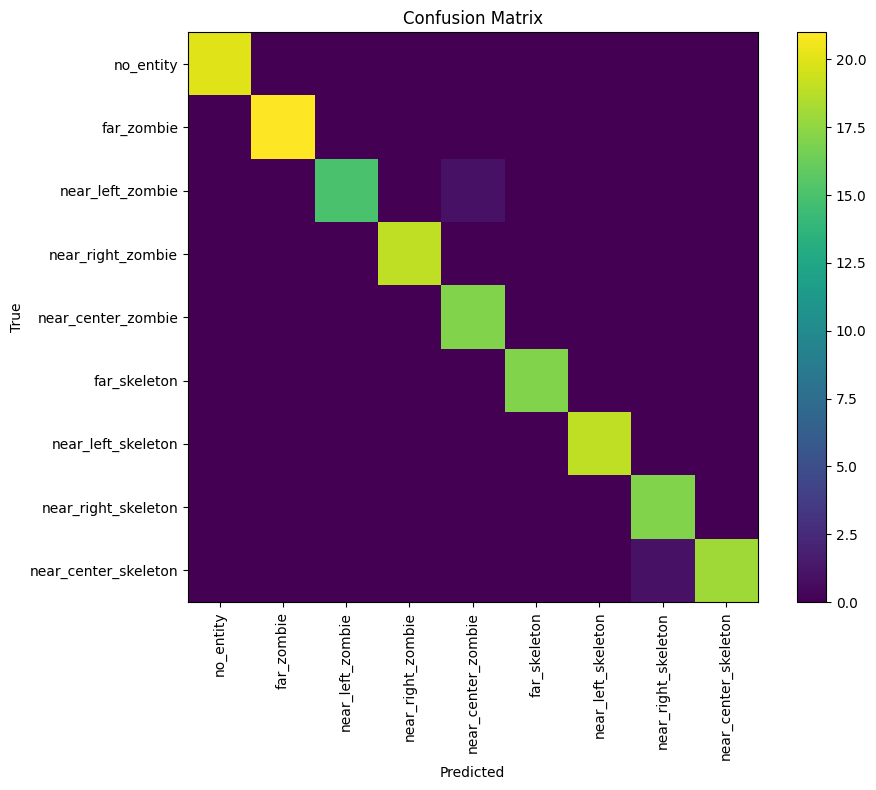

In [35]:
cm = confusion_matrix(val_labels, val_preds, labels=list(range(NUM_CLASSES)))

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=90)
plt.yticks(range(NUM_CLASSES), CLASS_NAMES)
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [36]:
def collect_predictions(model, loader):
    model.eval()

    results = []

    with torch.no_grad():
        for batch in loader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)
            paths = batch["paths"]

            with torch.cuda.amp.autocast(enabled=(USE_AMP and device == "cuda")):
                logits = model(pixel_values)

            preds = logits.argmax(dim=1)

            for path, y, p in zip(paths, labels.cpu().tolist(), preds.cpu().tolist()):
                results.append({
                    "path": path,
                    "true": y,
                    "pred": p,
                })

    return results


results = collect_predictions(model, val_loader)
wrong = [r for r in results if r["true"] != r["pred"]]

print("wrong:", len(wrong), "/", len(results))

/tmp/ipykernel_245903/2979052898.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and device == "cuda")):


wrong: 2 / 165


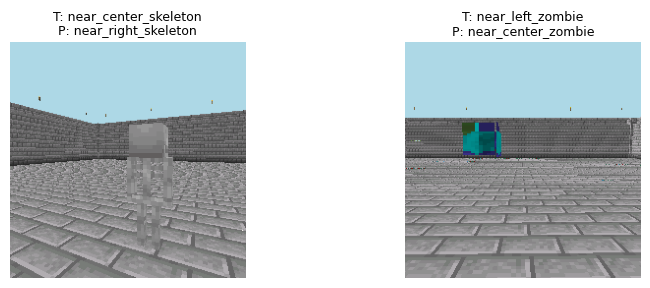

In [37]:
def show_wrong(wrong, n=9):
    if len(wrong) == 0:
        print("no wrong samples")
        return

    picks = random.sample(wrong, min(n, len(wrong)))

    plt.figure(figsize=(12, 8))

    for i, r in enumerate(picks):
        img = Image.open(r["path"]).convert("RGB")

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(
            f"T: {CLASS_NAMES[r['true']]}\nP: {CLASS_NAMES[r['pred']]}",
            fontsize=9,
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_wrong(wrong, 9)

In [23]:
checkpoint = torch.load(SAVE_PATH, map_location=device)

infer_model = SiglipArenaClassifier(NUM_CLASSES).to(device)
infer_model.load_state_dict(checkpoint["model_state_dict"])
infer_model.eval()

print("loaded:", SAVE_PATH)

Loading weights: 100%|██████████| 208/208 [00:00<00:00, 3171.57it/s]
[transformers] SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_pr

loaded: siglip_arena_classifier.pt


In [24]:
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")

    inputs = processor(
        images=[image],
        return_tensors="pt",
    )

    pixel_values = inputs["pixel_values"].to(device)

    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=(USE_AMP and device == "cuda")):
            logits = infer_model(pixel_values)

        probs = torch.softmax(logits, dim=1)[0]
        pred = probs.argmax().item()

    return {
        "class_id": pred,
        "class_name": CLASS_NAMES[pred],
        "prob": probs[pred].item(),
        "all_probs": probs.cpu().tolist(),
    }

arena_dataset/000700.png
1 far_zombie 0.9990234375


/tmp/ipykernel_245903/3492920545.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and device == "cuda")):


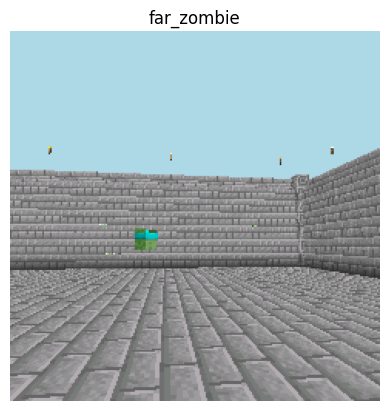

In [39]:
test_path = samples[700][0]

result = predict_image(test_path)

print(test_path)
print(result["class_id"], result["class_name"], result["prob"])

img = Image.open(test_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.title(result["class_name"])
plt.show()

In [40]:
# 모델/학습 객체 메모리 해제

import gc
import torch

# 필요하면 존재하는 변수만 삭제
for name in [
    "model",
    "infer_model",
    "encoder",
    "optimizer",
    "criterion",
    "scaler",
    "train_loader",
    "val_loader",
    "train_ds",
    "val_ds",
    "processor",
]:
    if name in globals():
        del globals()[name]

# Python garbage collection
gc.collect()

# CUDA cache 비우기
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    print("CUDA memory after cleanup")
    print("allocated:", torch.cuda.memory_allocated() / 1024**3, "GB")
    print("reserved :", torch.cuda.memory_reserved() / 1024**3, "GB")
else:
    print("CUDA not available")

CUDA memory after cleanup
allocated: 1.0568194389343262 GB
reserved : 1.3359375 GB
